In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("W:/Data-Science-Main/Data/housing-gurugram.csv")

In [3]:
df

,location,property_type,bedrooms,bathrooms,area_sqft,age_years,floor,parking_spaces,metro_distance_km,clubhouse,swimming_pool,gym,security_rating,price_inr
0,Sector 89,Apartment,3,4,2199,12,20,2,3.05,1,1,0,5,45127167
1,Sohna Road,Villa,2,3,1246,24,5,3,6.36,1,0,1,2,22401617
2,Golf Course Extension Road,Builder Floor,1,2,633,8,41,2,9.40,1,0,1,3,28080166
3,Sector 83,Apartment,4,4,3385,13,32,2,9.47,1,0,1,1,61408315
4,Sector 89,Apartment,3,3,1540,0,27,4,0.10,1,0,1,2,29451832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,New Gurgaon,Villa,3,4,1943,16,21,2,11.62,0,0,1,2,35126071
4996,DLF Phase 1,Apartment,3,4,1271,21,40,1,3.44,1,1,0,3,23631482
4997,Sector 92,Apartment,4,5,3064,12,24,1,1.48,1,0,0,1,54889125
4998,DLF Phase 2,Builder Floor,1,1,477,15,24,1,9.00,0,0,1,3,10770677


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   location           5000 non-null   str    
 1   property_type      5000 non-null   str    
 2   bedrooms           5000 non-null   int64  
 3   bathrooms          5000 non-null   int64  
 4   area_sqft          5000 non-null   int64  
 5   age_years          5000 non-null   int64  
 6   floor              5000 non-null   int64  
 7   parking_spaces     5000 non-null   int64  
 8   metro_distance_km  5000 non-null   float64
 9   clubhouse          5000 non-null   int64  
 10  swimming_pool      5000 non-null   int64  
 11  gym                5000 non-null   int64  
 12  security_rating    5000 non-null   int64  
 13  price_inr          5000 non-null   int64  
dtypes: float64(1), int64(11), str(2)
memory usage: 547.0 KB


In [5]:
df.isna().sum()

location             0
property_type        0
bedrooms             0
bathrooms            0
area_sqft            0
age_years            0
floor                0
parking_spaces       0
metro_distance_km    0
clubhouse            0
swimming_pool        0
gym                  0
security_rating      0
price_inr            0
dtype: int64

In [6]:
df.describe()

,bedrooms,bathrooms,area_sqft,age_years,floor,parking_spaces,metro_distance_km,clubhouse,swimming_pool,gym,security_rating,price_inr
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5.000000e+03
mean,2.955200,3.456800,1767.454000,12.13900,22.44180,1.844200,7.509842,0.645800,0.54120,0.707000,2.982200,3.689076e+07
std,1.012422,1.127115,735.122209,7.14604,12.64325,0.962763,4.295933,0.478318,0.49835,0.455184,1.414172,1.492816e+07
min,1.000000,1.000000,450.000000,0.00000,1.00000,0.000000,0.100000,0.000000,0.00000,0.000000,1.000000,3.500000e+06
25%,2.000000,3.000000,1233.000000,6.00000,12.00000,1.000000,3.797500,0.000000,0.00000,0.000000,2.000000,2.585450e+07
50%,3.000000,3.000000,1684.000000,12.00000,23.00000,2.000000,7.530000,1.000000,1.00000,1.000000,3.000000,3.578809e+07
75%,4.000000,4.000000,2218.250000,18.00000,33.00000,2.000000,11.220000,1.000000,1.00000,1.000000,4.000000,4.612477e+07
max,5.000000,6.000000,4865.000000,24.00000,44.00000,4.000000,14.990000,1.000000,1.00000,1.000000,5.000000,9.878816e+07


In [7]:
df['location'].unique()

<StringArray>
[                 'Sector 89',                 'Sohna Road',
 'Golf Course Extension Road',                  'Sector 83',
           'Golf Course Road',                  'Sector 92',
                'New Gurgaon',                  'Sector 54',
                'DLF Phase 5',                  'Sector 82',
                'DLF Phase 3',               'South City 1',
                  'Sector 57',                  'Sector 84',
                  'Sector 56',                  'Sector 70',
                  'Sector 65',                'DLF Phase 2',
                'DLF Phase 1',                'DLF Phase 4',
                  'Sector 67',                'Palam Vihar',
                  'Sector 85']
Length: 23, dtype: str

In [8]:
df['property_type'].unique()

<StringArray>
['Apartment', 'Villa', 'Builder Floor', 'Penthouse']
Length: 4, dtype: str

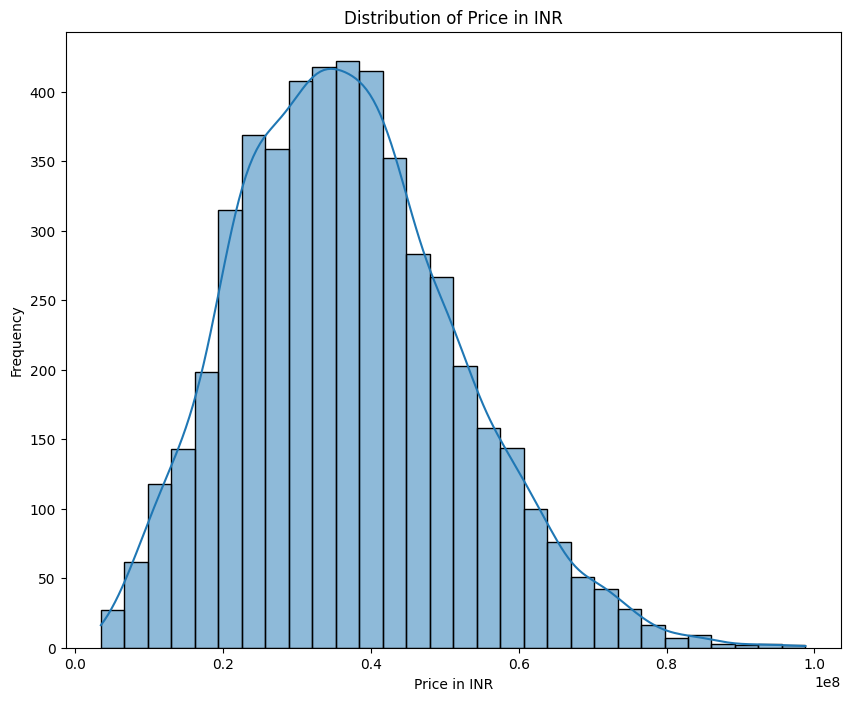

In [9]:
plt.figure(figsize=(10, 8))
sns.histplot(df['price_inr'], bins=30, kde=True)
plt.title('Distribution of Price in INR')
plt.xlabel('Price in INR')
plt.ylabel('Frequency')
plt.show()

In [10]:
categorical_cols = ['location', 'property_type']

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [11]:
df

,bedrooms,bathrooms,area_sqft,age_years,floor,parking_spaces,metro_distance_km,clubhouse,swimming_pool,gym,...,location_Sector 83,location_Sector 84,location_Sector 85,location_Sector 89,location_Sector 92,location_Sohna Road,location_South City 1,property_type_Builder Floor,property_type_Penthouse,property_type_Villa
0,3,4,2199,12,20,2,3.05,1,1,0,...,False,False,False,True,False,False,False,False,False,False
1,2,3,1246,24,5,3,6.36,1,0,1,...,False,False,False,False,False,True,False,False,False,True
2,1,2,633,8,41,2,9.40,1,0,1,...,False,False,False,False,False,False,False,True,False,False
3,4,4,3385,13,32,2,9.47,1,0,1,...,True,False,False,False,False,False,False,False,False,False
4,3,3,1540,0,27,4,0.10,1,0,1,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,3,4,1943,16,21,2,11.62,0,0,1,...,False,False,False,False,False,False,False,False,False,True
4996,3,4,1271,21,40,1,3.44,1,1,0,...,False,False,False,False,False,False,False,False,False,False
4997,4,5,3064,12,24,1,1.48,1,0,0,...,False,False,False,False,True,False,False,False,False,False
4998,1,1,477,15,24,1,9.00,0,0,1,...,False,False,False,False,False,False,False,True,False,False


In [12]:
df.describe()

,bedrooms,bathrooms,area_sqft,age_years,floor,parking_spaces,metro_distance_km,clubhouse,swimming_pool,gym,security_rating,price_inr
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5.000000e+03
mean,2.955200,3.456800,1767.454000,12.13900,22.44180,1.844200,7.509842,0.645800,0.54120,0.707000,2.982200,3.689076e+07
std,1.012422,1.127115,735.122209,7.14604,12.64325,0.962763,4.295933,0.478318,0.49835,0.455184,1.414172,1.492816e+07
min,1.000000,1.000000,450.000000,0.00000,1.00000,0.000000,0.100000,0.000000,0.00000,0.000000,1.000000,3.500000e+06
25%,2.000000,3.000000,1233.000000,6.00000,12.00000,1.000000,3.797500,0.000000,0.00000,0.000000,2.000000,2.585450e+07
50%,3.000000,3.000000,1684.000000,12.00000,23.00000,2.000000,7.530000,1.000000,1.00000,1.000000,3.000000,3.578809e+07
75%,4.000000,4.000000,2218.250000,18.00000,33.00000,2.000000,11.220000,1.000000,1.00000,1.000000,4.000000,4.612477e+07
max,5.000000,6.000000,4865.000000,24.00000,44.00000,4.000000,14.990000,1.000000,1.00000,1.000000,5.000000,9.878816e+07


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   bedrooms                             5000 non-null   int64  
 1   bathrooms                            5000 non-null   int64  
 2   area_sqft                            5000 non-null   int64  
 3   age_years                            5000 non-null   int64  
 4   floor                                5000 non-null   int64  
 5   parking_spaces                       5000 non-null   int64  
 6   metro_distance_km                    5000 non-null   float64
 7   clubhouse                            5000 non-null   int64  
 8   swimming_pool                        5000 non-null   int64  
 9   gym                                  5000 non-null   int64  
 10  security_rating                      5000 non-null   int64  
 11  price_inr                            5000

In [14]:
df.shape

(5000, 37)

In [15]:
x1 = df.drop('price_inr', axis=1)
y1 = df['price_inr']

In [16]:
xTrain, xTest, yTrain, yTest = train_test_split(x1, y1, test_size=0.2, random_state=42)

In [17]:
model = LinearRegression()
model.fit(xTrain, yTrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
pricePrediction = model.predict(xTest)

In [19]:
mse = mean_squared_error(yTest, pricePrediction)
rmse = root_mean_squared_error(yTest, pricePrediction)
r2 = r2_score(yTest, pricePrediction)
r2Val = r2*100

In [20]:
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared Score: {r2Val:.2f}%")

Mean Squared Error (MSE): 8744613029656.866
Root Mean Squared Error (RMSE): 2957129.1871774667
R-squared Score: 95.88%


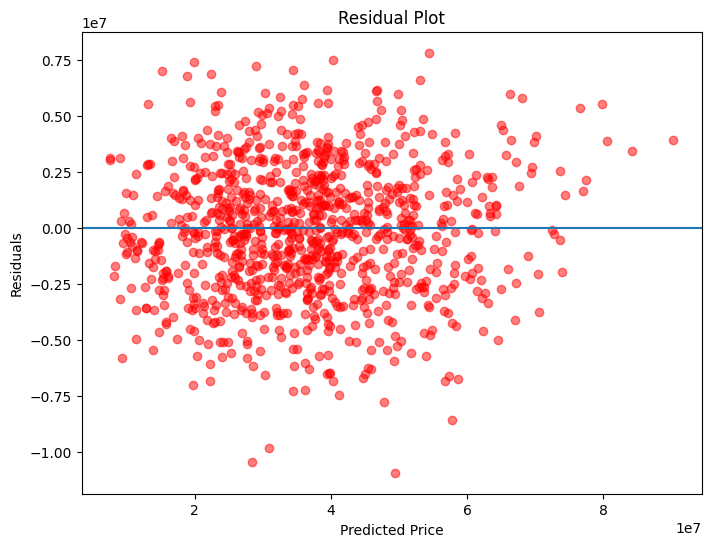

In [24]:
residuals = yTest - pricePrediction

plt.figure(figsize=(8,6))
plt.scatter(pricePrediction, residuals, alpha=0.5, color='red')
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

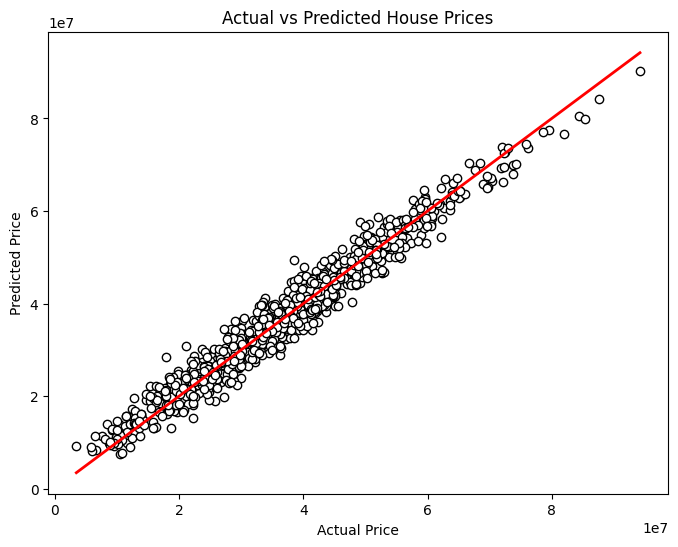

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(yTest, pricePrediction, alpha=1, color='white', edgecolor='black')
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], color='red', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()